In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math as m
import seaborn as sns


In [110]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data Collection

In [111]:
df = pd.read_csv("/content/drive/MyDrive/aDA/train.csv")

In [112]:
df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73,0


In [113]:
df.shape

(54808, 13)

# Data Preparation

In [114]:
df.isnull().sum()

,0
employee_id,0
department,0
region,0
education,2409
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,4124
length_of_service,0


In [115]:
for col in df:

    x = df[col].value_counts().count()
    print(F"{col} : {x}")

employee_id : 54808
department : 9
region : 34
education : 3
gender : 2
recruitment_channel : 3
no_of_trainings : 10
age : 41
previous_year_rating : 5
length_of_service : 35
awards_won? : 2
avg_training_score : 61
is_promoted : 2


## pie chart for categorical 1 - 5 item

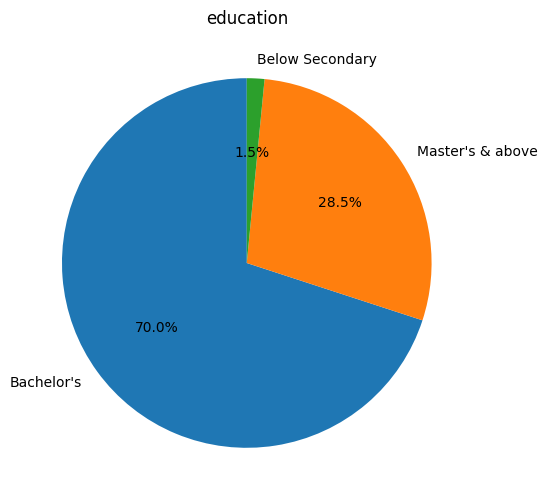

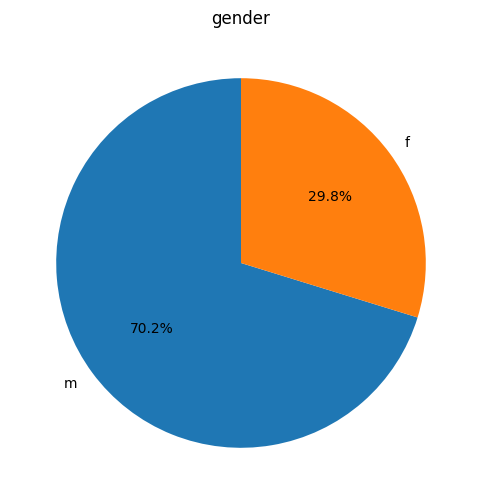

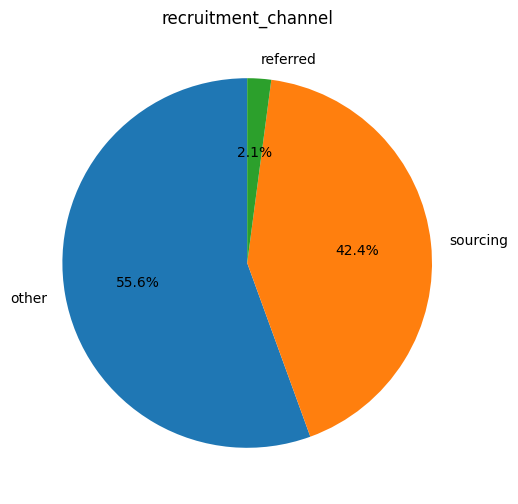

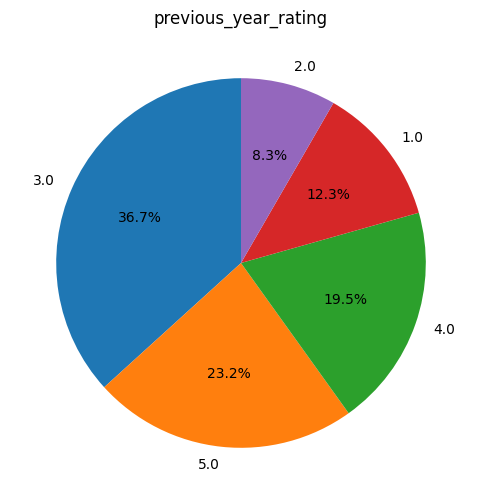

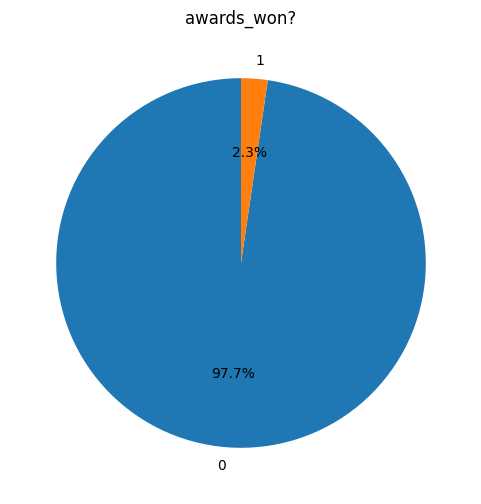

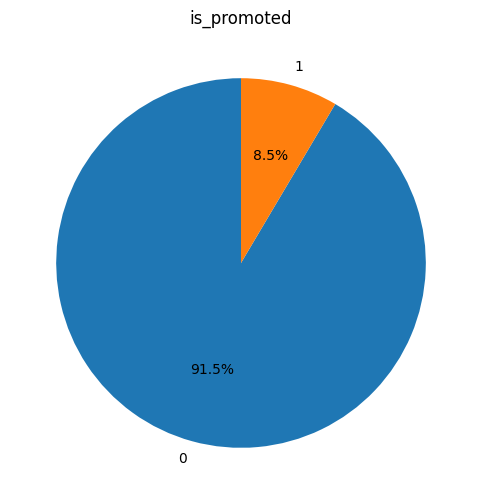

In [116]:


categorical_columns = ['education','gender', 'recruitment_channel','previous_year_rating','awards_won?',  'is_promoted']

for col in categorical_columns:
    counts = df[col].value_counts()

    plt.figure(figsize=(6,6))
    plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%', startangle=90)
    plt.title(col)
    plt.show()

In [117]:
df_copy = df.copy()
df_copy=df_copy.drop(["age","employee_id","region", "length_of_service", 'avg_training_score'],axis = 1)
for col in df_copy:

    counts = df[col].value_counts()
    print(counts, end="\n---------------------------------------\n")


department
Sales & Marketing    16840
Operations           11348
Technology            7138
Procurement           7138
Analytics             5352
Finance               2536
HR                    2418
Legal                 1039
R&D                    999
Name: count, dtype: int64
---------------------------------------
education
Bachelor's          36669
Master's & above    14925
Below Secondary       805
Name: count, dtype: int64
---------------------------------------
gender
m    38496
f    16312
Name: count, dtype: int64
---------------------------------------
recruitment_channel
other       30446
sourcing    23220
referred     1142
Name: count, dtype: int64
---------------------------------------
no_of_trainings
1     44378
2      7987
3      1776
4       468
5       128
6        44
7        12
8         5
10        5
9         5
Name: count, dtype: int64
---------------------------------------
previous_year_rating
3.0    18618
5.0    11741
4.0     9877
1.0     6223
2.0     4225
Nam

##missing solve

In [118]:
df['previous_year_rating'].mode()

,previous_year_rating
0,3.0


In [119]:
df['education'].mode()

,education
0,Bachelor's


In [120]:
from sklearn.impute import SimpleImputer

col_mi = ["previous_year_rating", "education"]

imputer = SimpleImputer(strategy='most_frequent')
df[col_mi] = imputer.fit_transform(df[col_mi])

In [121]:
df.isnull().sum()

,0
employee_id,0
department,0
region,0
education,0
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,0
length_of_service,0


###numerical plot

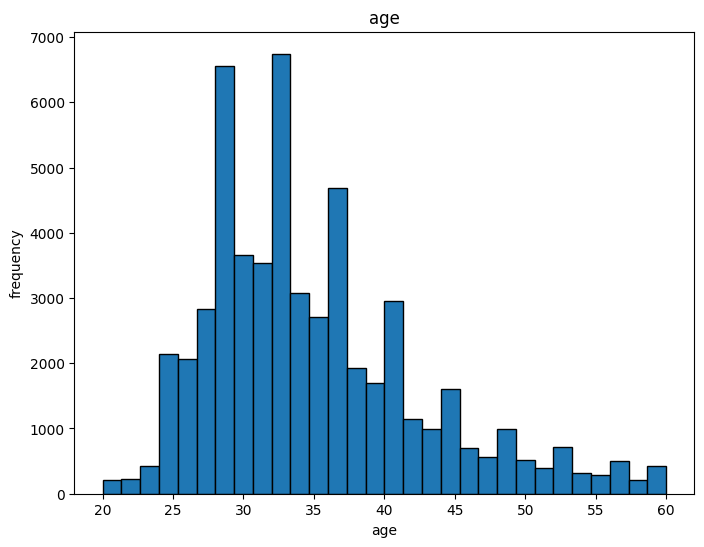

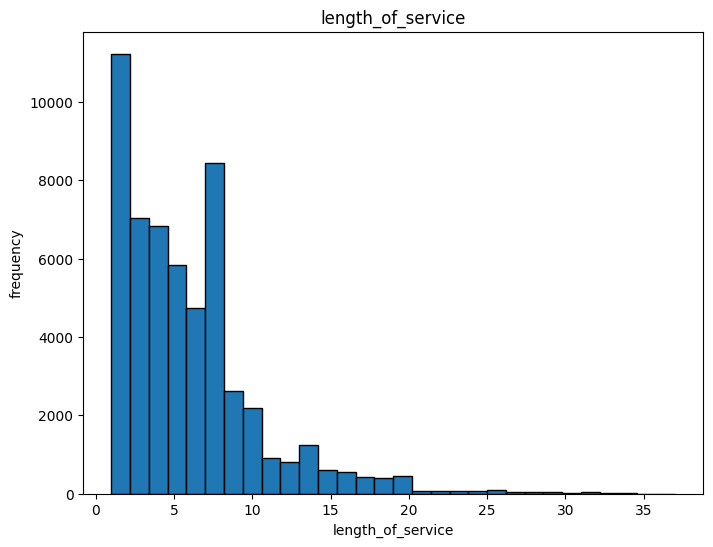

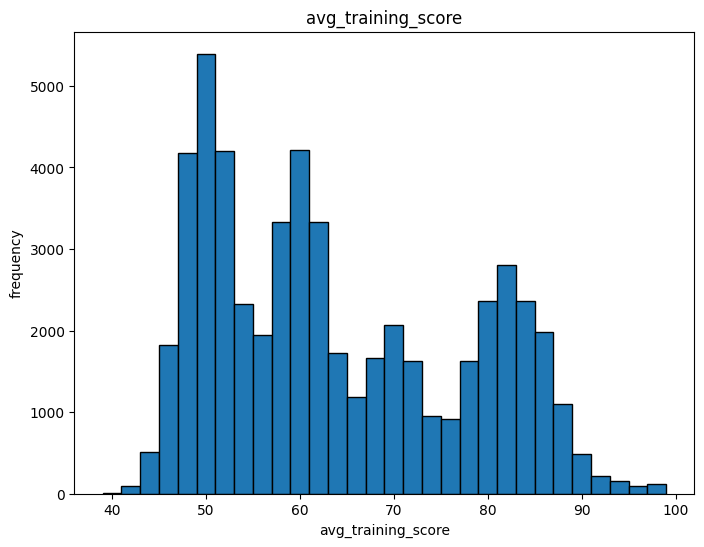

In [122]:
num_col = ["age", "length_of_service", 'avg_training_score']
for col in num_col:
    plt.figure(figsize=(8,6))
    plt.hist(df[col], bins=30, edgecolor='black')
    plt.xlabel(col)
    plt.ylabel('frequency')
    plt.title(col)
    plt.show()

<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-888627426.py:5: SyntaxWarning: invalid escape sequence '\d'
  region_counts_sorted = region_counts.sort_index(key=lambda x: x.str.extract('(\d+)').astype(int)[0])


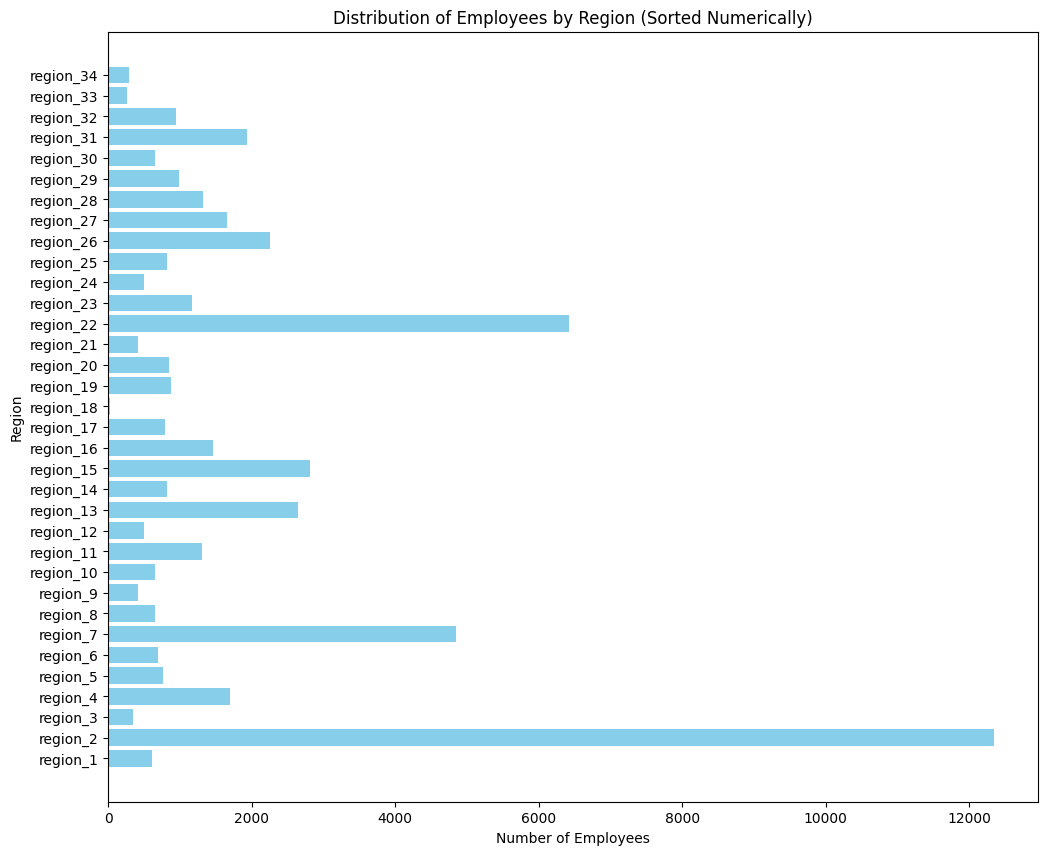

In [123]:
import matplotlib.pyplot as plt

region_counts = df['region'].value_counts()

region_counts_sorted = region_counts.sort_index(key=lambda x: x.str.extract('(\d+)').astype(int)[0])

plt.figure(figsize=(12,10))
plt.barh(region_counts_sorted.index, region_counts_sorted.values, color='skyblue')
plt.xlabel("Number of Employees")
plt.ylabel("Region")
plt.title("Distribution of Employees by Region (Sorted Numerically)")
plt.show()


In [124]:
df['age'].mean()

np.float64(34.80391548679025)

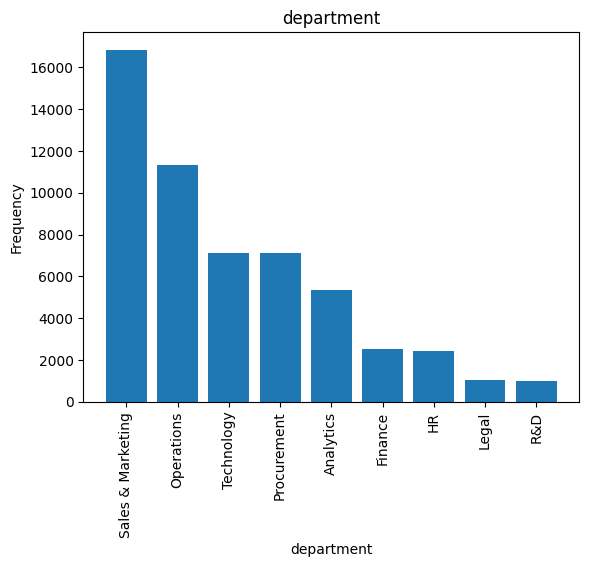

In [125]:
disdep = df['department'].value_counts()

plt.bar(disdep.index, disdep.values)
plt.xlabel('department')
plt.ylabel("Frequency")
plt.title('department')
plt.xticks(rotation=90)
plt.show()

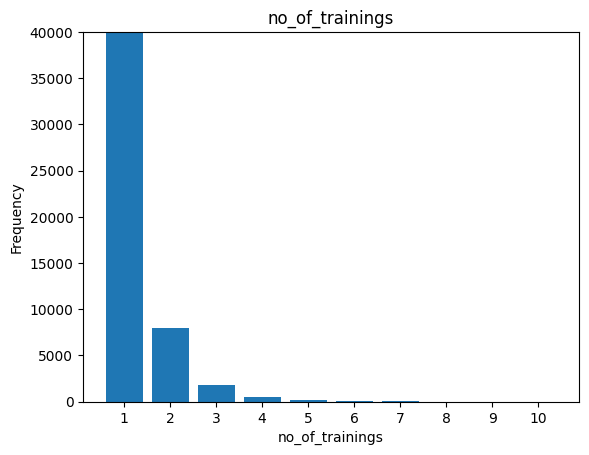

In [126]:
noft = df['no_of_trainings'].value_counts()

plt.bar(noft.index, noft.values)
plt.xlabel("no_of_trainings")
plt.ylabel("Frequency")
plt.title("no_of_trainings")
plt.xticks(noft.index)
plt.ylim(0,40000)
plt.show()

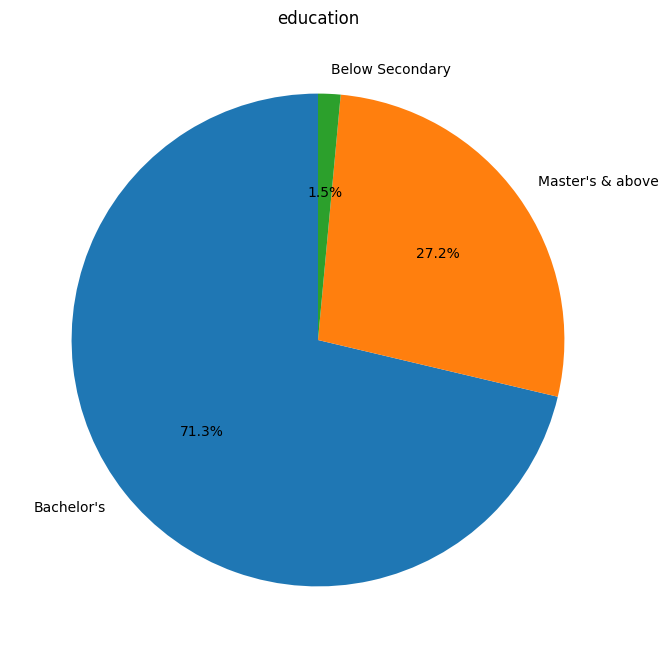

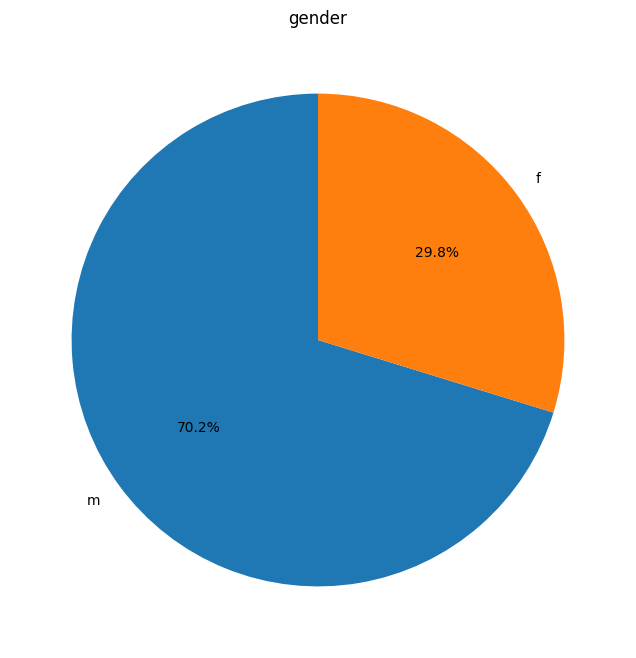

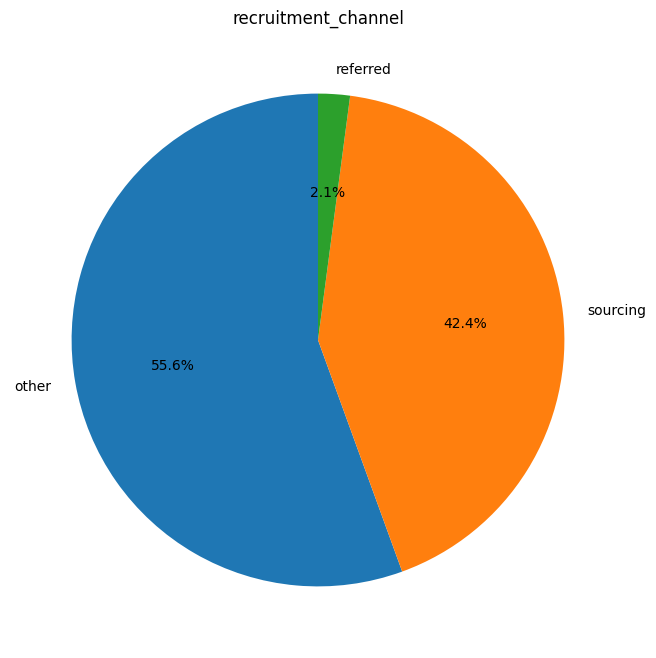

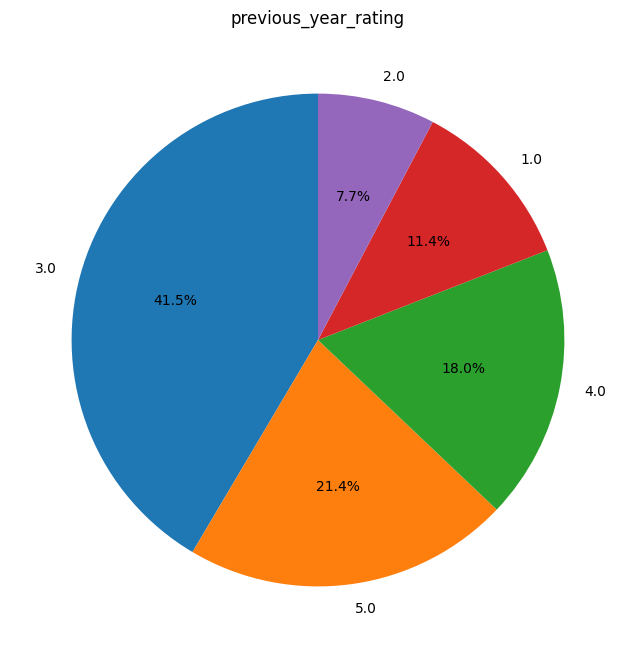

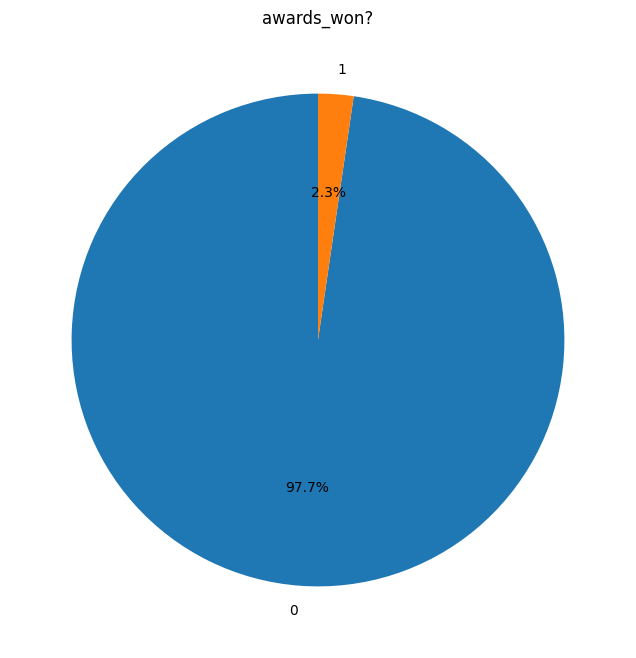

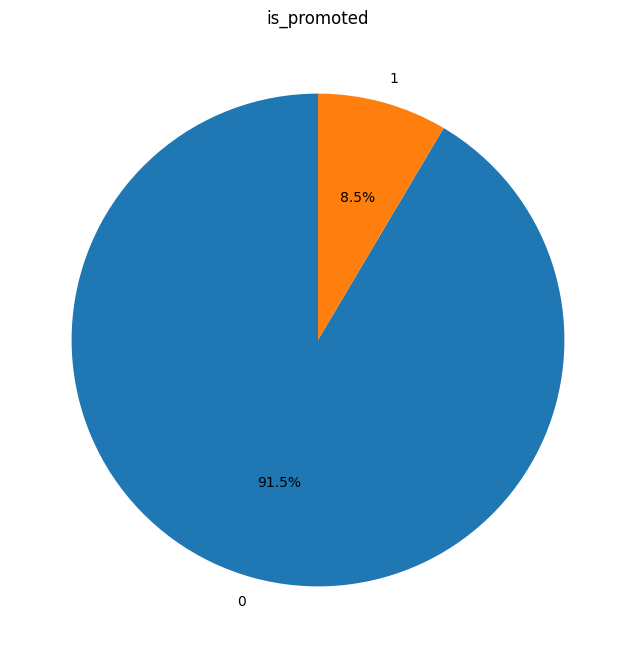

In [127]:
categorical_columns = ['education','gender', 'recruitment_channel','previous_year_rating','awards_won?',  'is_promoted']

for col in categorical_columns:
    counts = df[col].value_counts()

    plt.figure(figsize=(8,8))
    plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%', startangle=90)
    plt.title(col)
    plt.show()

###Correlation

In [128]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

label_enc = ['department', 'region', 'education', 'gender', 'recruitment_channel']

le = LabelEncoder()
for col in label_enc:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))


corr = df_encoded.corr()
corr

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
employee_id,1.000000,-0.005187,-0.003423,0.002124,-0.001542,0.005960,-0.005121,0.000437,0.004209,0.001274,0.008420,-0.000586,0.001206
department,-0.005187,1.000000,-0.020592,0.043441,-0.030108,0.004732,0.014152,0.079162,-0.135561,0.059060,-0.002151,-0.251626,0.000130
region,-0.003423,-0.020592,1.000000,-0.003815,0.019730,-0.000920,-0.004590,-0.088918,-0.005977,-0.058939,0.000307,0.023572,0.008841
education,0.002124,0.043441,-0.003815,1.000000,-0.032368,-0.003564,-0.033469,0.339966,0.027393,0.233666,-0.001409,0.032787,0.029257
gender,-0.001542,-0.030108,0.019730,-0.032368,1.000000,0.006567,0.084501,-0.016293,-0.024024,-0.019675,0.002381,-0.024494,-0.011109
recruitment_channel,0.005960,0.004732,-0.000920,-0.003564,0.006567,1.000000,-0.010405,-0.011400,0.005731,-0.002887,-0.005510,-0.002416,0.002229
no_of_trainings,-0.005121,0.014152,-0.004590,-0.033469,0.084501,-0.010405,1.000000,-0.081278,-0.061564,-0.057275,-0.007628,0.042517,-0.024896
age,0.000437,0.079162,-0.088918,0.339966,-0.016293,-0.011400,-0.081278,1.000000,0.026810,0.657111,-0.008169,-0.048380,-0.017166
previous_year_rating,0.004209,-0.135561,-0.005977,0.027393,-0.024024,0.005731,-0.061564,0.026810,1.000000,0.023504,0.026587,0.071926,0.153230
length_of_service,0.001274,0.059060,-0.058939,0.233666,-0.019675,-0.002887,-0.057275,0.657111,0.023504,1.000000,-0.039927,-0.038122,-0.010670


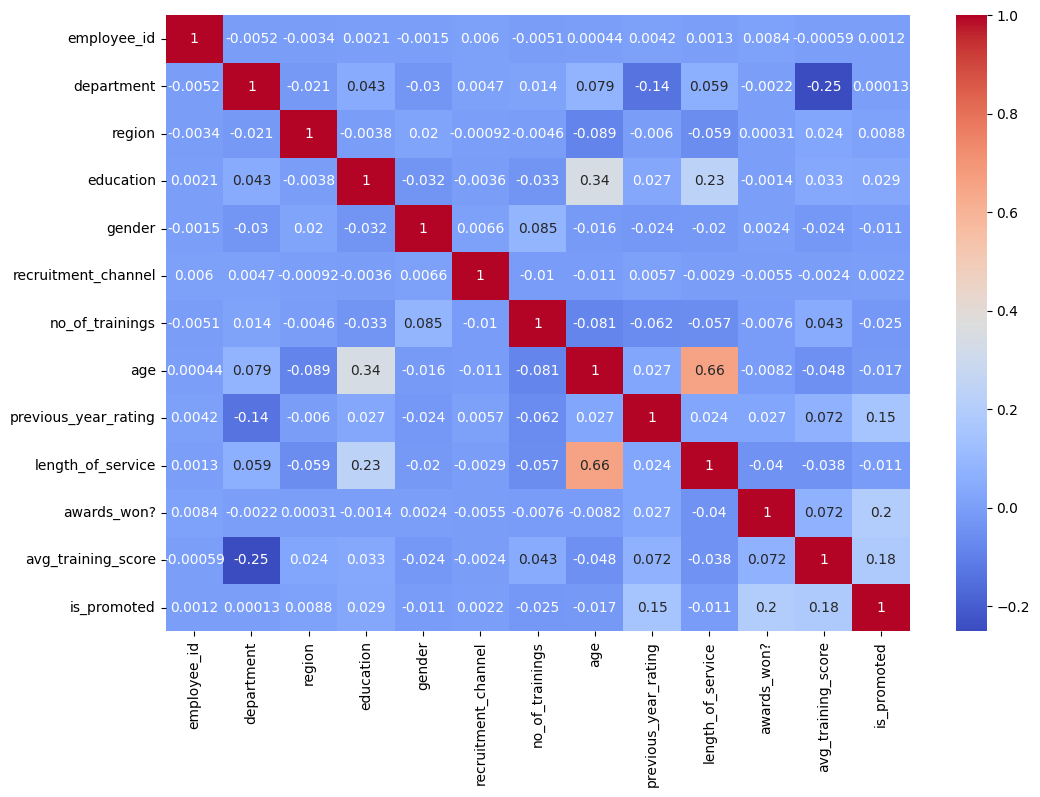

In [129]:
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [130]:
df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73,0


## last presentation

In [151]:

train_df = df.copy()
train_df = train_df.drop("employee_id", axis=1)

In [152]:
train_df

,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
0,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49,0
1,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60,0
2,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50,0
3,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50,0
4,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73,0
...,...,...,...,...,...,...,...,...,...,...,...,...
54803,Technology,region_14,Bachelor's,m,sourcing,1,48,3.0,17,0,78,0
54804,Operations,region_27,Master's & above,f,other,1,37,2.0,6,0,56,0
54805,Analytics,region_1,Bachelor's,m,other,1,27,5.0,3,0,79,0
54806,Sales & Marketing,region_9,Bachelor's,m,sourcing,1,29,1.0,2,0,45,0


In [133]:
csv_tset  = pd.read_csv("/content/drive/MyDrive/aDA/test.csv")
# csv_tset = csv_tset.drop("employee_id", axis=1)
csv_tset.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score
0,8724,Technology,region_26,Bachelor's,m,sourcing,1,24,NaN,1,0,77
1,74430,HR,region_4,Bachelor's,f,other,1,31,3.0,5,0,51
2,72255,Sales & Marketing,region_13,Bachelor's,m,other,1,31,1.0,4,0,47
3,38562,Procurement,region_2,Bachelor's,f,other,3,31,2.0,9,0,65
4,64486,Finance,region_29,Bachelor's,m,sourcing,1,30,4.0,7,0,61


In [134]:
csv_tset.isnull().sum()

,0
employee_id,0
department,0
region,0
education,1034
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,1812
length_of_service,0


In [135]:
from sklearn.impute import SimpleImputer

col_mi = ["previous_year_rating", "education"]

imputer = SimpleImputer(strategy='most_frequent')
csv_tset[col_mi] = imputer.fit_transform(csv_tset[col_mi])

In [136]:
csv_tset.isnull().sum()

,0
employee_id,0
department,0
region,0
education,0
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,0
length_of_service,0


In [137]:
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

X = df.drop("is_promoted", axis=1)
y = df["is_promoted"]

In [138]:
cat_cols = [
    "department", "region", "education",
    "gender", "recruitment_channel"
]

num_cols = [
    "no_of_trainings", "age", "previous_year_rating",
    "length_of_service", "awards_won?", "avg_training_score"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
        ("num", MinMaxScaler(), num_cols)
    ]
)

X_processed = preprocessor.fit_transform(X)

ohe_cols = preprocessor.named_transformers_["cat"].get_feature_names_out(cat_cols)

final_cols = list(ohe_cols) + num_cols

X_processed_df = pd.DataFrame(X_processed.toarray(), columns=final_cols)

X_processed_df.head()

,department_Finance,department_HR,department_Legal,department_Operations,department_Procurement,department_R&D,department_Sales & Marketing,department_Technology,region_region_10,region_region_11,...,education_Master's & above,gender_m,recruitment_channel_referred,recruitment_channel_sourcing,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.000000,0.375,1.0,0.194444,0.0,0.166667
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.000000,0.250,1.0,0.083333,0.0,0.350000
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.000000,0.350,0.5,0.166667,0.0,0.183333
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.111111,0.475,0.0,0.250000,0.0,0.183333
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.000000,0.625,0.5,0.027778,0.0,0.566667


In [139]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed_df, y, test_size=0.2, random_state=42
)

In [140]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

### Logistic Regression

In [141]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
acc_log = accuracy_score(y_test, y_pred_log)

print("Logistic Regression:", round(acc_log, 4))

Logistic Regression: 0.9361


### Random Forest

In [142]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest      :", round(acc_rf, 4))

Random Forest      : 0.9265


### XGBoost

In [143]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb)

print("XGBoost            :", round(acc_xgb, 4))

XGBoost            : 0.9437


In [144]:
gx_pre = csv_tset.copy()
gx_pre.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score
0,8724,Technology,region_26,Bachelor's,m,sourcing,1,24,3.0,1,0,77
1,74430,HR,region_4,Bachelor's,f,other,1,31,3.0,5,0,51
2,72255,Sales & Marketing,region_13,Bachelor's,m,other,1,31,1.0,4,0,47
3,38562,Procurement,region_2,Bachelor's,f,other,3,31,2.0,9,0,65
4,64486,Finance,region_29,Bachelor's,m,sourcing,1,30,4.0,7,0,61


In [145]:
X_test_final = preprocessor.transform(gx_pre)

In [146]:
X_test_final

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 172642 stored elements and shape (23490, 52)>

In [147]:
X_test_final_df = pd.DataFrame(
    X_test_final.toarray(),
    columns=final_cols
)

In [148]:
gx_pre["is_promoted_pred"] = xgb_model.predict(X_test_final_df)

In [149]:
gx_pre

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted_pred
0,8724,Technology,region_26,Bachelor's,m,sourcing,1,24,3.0,1,0,77,0
1,74430,HR,region_4,Bachelor's,f,other,1,31,3.0,5,0,51,0
2,72255,Sales & Marketing,region_13,Bachelor's,m,other,1,31,1.0,4,0,47,0
3,38562,Procurement,region_2,Bachelor's,f,other,3,31,2.0,9,0,65,0
4,64486,Finance,region_29,Bachelor's,m,sourcing,1,30,4.0,7,0,61,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23485,53478,Legal,region_2,Below Secondary,m,sourcing,1,24,3.0,1,0,61,0
23486,25600,Technology,region_25,Bachelor's,m,sourcing,1,31,3.0,7,0,74,0
23487,45409,HR,region_16,Bachelor's,f,sourcing,1,26,4.0,4,0,50,0
23488,1186,Procurement,region_31,Bachelor's,m,sourcing,3,27,3.0,1,0,70,0


In [150]:
gx_pre["is_promoted_pred"].value_counts()

,count
is_promoted_pred,
0,22760
1,730
